# **PROJECT TITLE:- SHOPPERS SPECTRUM using RFM-Based Customer Segmentation and Product Recommendation System**

# **Objective of This Notebook**

This notebook focuses on understanding, cleaning, and preparing raw e-commerce transaction data to make it suitable for customer segmentation and product recommendation.
The goal is to transform unstructured transactional data into business-relevant features that can drive meaningful insights.

# **Why Data Evaluation Is Important**

Raw e-commerce data often contains:

Missing customer identifiers

Cancelled transactions

Negative or zero quantities and prices

Duplicate or inconsistent records

If these issues are not addressed early, they can mislead analysis, distort customer behavior, and reduce model accuracy.
Therefore, proper data evaluation ensures that all downstream insights and models are reliable.

# **STEP 1: Data Preprocessing & Cleaning**

# **Why Data Cleaning Is Necessary**

E-commerce transaction data often contains invalid, incomplete, or noisy records that do not represent real customer behavior.
If such data is used directly, it can:

Distort customer spending patterns

Create misleading customer segments

Reduce the effectiveness of recommendation systems

Therefore, data preprocessing is a critical foundation step to ensure model reliability and business accuracy.

# **Dataset Loading & Initial Exploration**
**Purpose of This Step**

Before performing any data cleaning or analysis, it is essential to load the dataset and understand its basic structure.
This helps verify that the data has been imported correctly and provides an initial sense of its size and complexity.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/online_retail.csv")


# Next step is to check for number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (541909, 8)


# **Missing Value Analysis**
**Purpose of This Step**

Missing values can significantly affect both customer segmentation and recommendation accuracy.
Before cleaning the data, it is important to identify which columns contain missing information and how extensive the issue is.

In [2]:
# Check total missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


# **Handling Missing CustomerID Values**
**Problem Identified**

Some transactions in the dataset do not contain a CustomerID.
Since customer segmentation and RFM analysis rely on identifying individual customers, missing customer identifiers must be handled carefully.

In [3]:
# Now we will fill the missing values for CustomerID using -1 for unknown customer
df['CustomerID'] = df['CustomerID'].fillna(-1)

# Now let's covert CustomerID to integer for consistency
df['CustomerID'] = df['CustomerID'].astype(int)

# Now we will verify if the missing values are filled or not
print("Missing CustomerID after filling:")
print(df['CustomerID'].isnull().sum())

Missing CustomerID after filling:
0


# **Identification of Cancelled Transactions**
**Purpose of This Step**

In e-commerce datasets, cancelled invoices represent reversed or unsuccessful transactions.
Including them in analysis can distort customer spending patterns and lead to inaccurate RFM values.

In [4]:
# Next step is to check how many cancelled invoices are present
cancelled_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print(f"Number of cancelled invoices: {cancelled_count}")

Number of cancelled invoices: 9288


# **Removal of Cancelled Transactions**
**Why Cancelled Invoices Are Removed**

Cancelled invoices represent transactions that did not result in a completed sale.
Including them would:

Distort total spending calculations

Misrepresent customer purchase frequency

Lead to inaccurate RFM values

Since the goal of this project is to analyze actual customer purchasing behavior, cancelled transactions must be excluded.

In [5]:
# Next step is to remove the cancelled invoices which starts with 'C'
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Now we will verify the removal 
# Re-check cancelled invoices after removal
remaining_cancelled = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print(f"Cancelled invoices after cleaning: {remaining_cancelled}")

Cancelled invoices after cleaning: 0


# **Validation of Quantity and Price Values**
**Purpose of This Step**

In retail transaction data, quantity and unit price must always be positive to represent a valid purchase.
Zero or negative values typically indicate:

Returns

Data entry errors

System-generated adjustments

Such records do not reflect genuine customer purchasing behavior and must be handled carefully.

In [6]:
# Next step is to count the invalid data for the records of quantity
invalid_quantity = (df['Quantity'] <= 0).sum()

# Next step is to count the invalid data for the records of price
invalid_price = (df['UnitPrice'] <= 0).sum()

print(f"Rows with Quantity ≤ 0: {invalid_quantity}")
print(f"Rows with UnitPrice ≤ 0: {invalid_price}")

Rows with Quantity ≤ 0: 1336
Rows with UnitPrice ≤ 0: 2517


# **Removal of Invalid Records and Duplicate Transactions**
**Purpose of This Step**

After identifying invalid quantity and price values, the next step is to remove these records entirely to ensure that the dataset reflects only genuine purchase transactions.
Additionally, duplicate records can inflate transaction counts and distort customer behavior metrics, making their removal essential.

In [7]:
# Next step is to remove the rows with invalid data like quantity and price records is less than or equal to 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Next step is to check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Now we will drop the duplicate rows
# Remove duplicate rows
df = df.drop_duplicates()

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows after cleaning: {duplicate_rows}")

Number of duplicate rows: 5226
Number of duplicate rows after cleaning: 0


# **Feature Preparation**

In this step, we transform raw transactional data into meaningful features that can be used for customer behavior analysis, segmentation, and recommendation modeling.

# **Why this step is important**

Raw data alone cannot directly answer business questions. Feature preparation helps convert operational data into analytical variables that reflect customer value and purchasing behavior.

# **1. Converting Invoice Date to DateTime**

The InvoiceDate column is converted into a datetime format to enable:

Accurate time-based calculations

Recency analysis for RFM segmentation

Chronological sorting of transactions

This conversion is essential for understanding when customers last purchased, which directly influences customer segmentation.

# **2. Creating TotalPrice Feature**

A new feature called TotalPrice is created by multiplying Quantity and UnitPrice.

Why this matters:

It represents the actual revenue generated per transaction

Forms the basis of the Monetary component in RFM analysis

Helps identify high-value customers and top-performing products

# **3. Validation of Feature Engineering**

df.dtypes is used to verify that data types are correctly assigned

df.head() is used to visually confirm successful feature creation and data consistency

In [8]:
# Convert InvoiceDate column to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Now we will verify the updates
print(df.dtypes)

# Now we will preview the final dataset after cleaning
df.head()

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


# **STEP 2: EXPLORATORY DATA ANALYSIS (EDA)**

Exploratory Data Analysis (EDA) helps in understanding customer behavior and overall business performance before applying machine learning models.

**In this step, we analyze:**

Customer purchasing patterns

Sales distribution across products and regions

Spending behavior over time

Popular products and high-revenue customers

# **Objectives of EDA**

**The primary goals of EDA in this project are:**

To identify key markets and customer segments

To detect trends, seasonality, and purchasing frequency

To understand revenue concentration among customers and products

To validate assumptions used in RFM segmentation and recommendation systems

# **1. Transaction Volume by Country**
This plot is used to Visualise the number of Transactions made by each Country. This plot is used to visualise the Geographical Distributions of Customer Purchase. By comparing transaction volumes across countries, we can identify which regions contribute the most to overall sales activity. This insight is useful for recognizing key markets, focusing marketing efforts, and making region-specific business decisions.

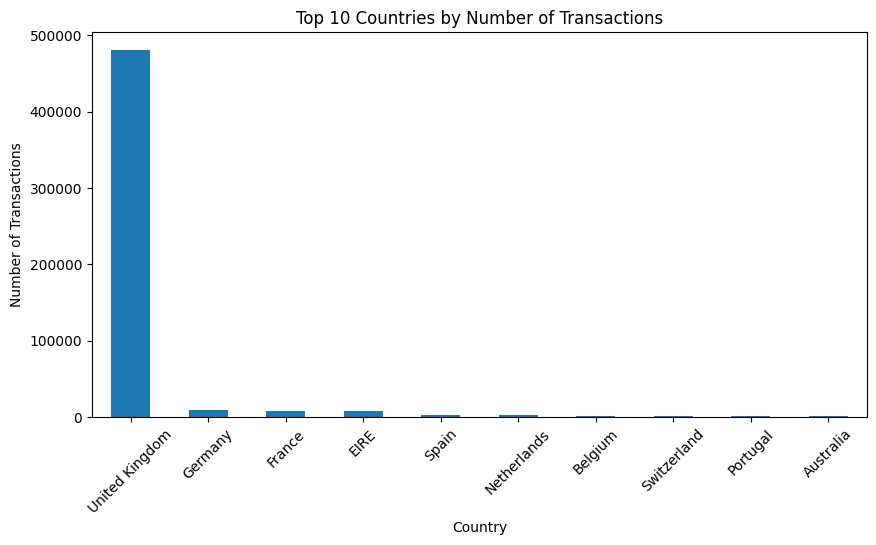

In [9]:
import matplotlib.pyplot as plt

# Transaction count by country
country_transactions = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_transactions.plot(kind='bar')
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

# **Observation**

Most of the transactions come from the United Kingdom, far more than any other country.
Other countries contribute only a small number of transactions in comparison.
This shows that the UK is the main customer base for the business.

# **2. Top-Selling Products**
This plot shows the top-selling products based on total quantity sold, highlighting which items are most popular among customers. By visualizing product-wise sales volume, we can identify high-demand products that significantly contribute to overall sales. These insights are valuable for inventory planning, promotional strategies, and building effective product recommendation systems.

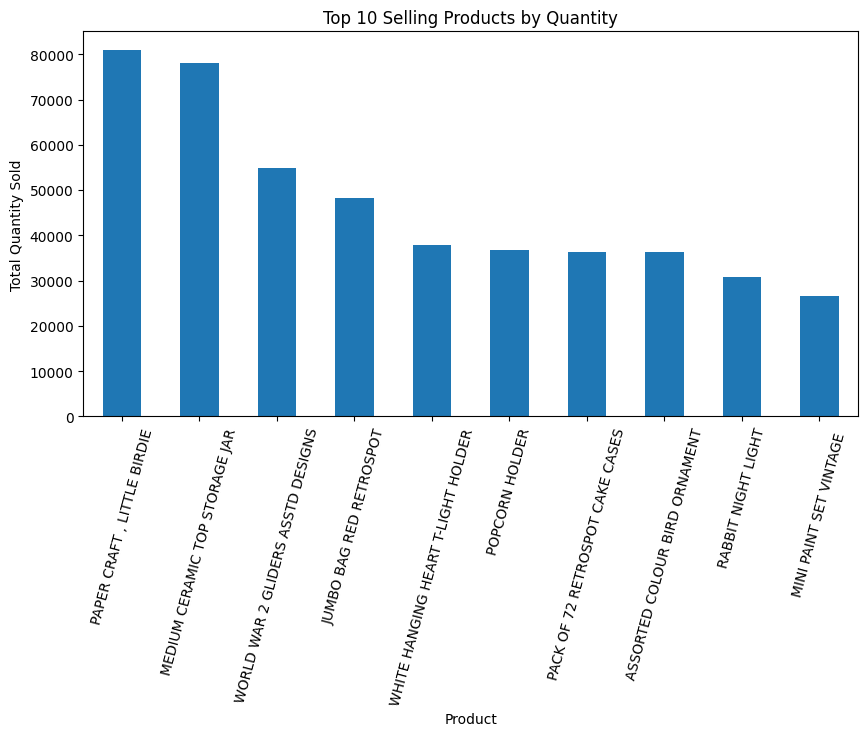

In [10]:
# Top-selling products by quantity
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75)
plt.show()

# **Observation**

A few products are sold much more than others, showing they are very popular among customers.
These products play an important role in overall sales and should be prioritized for stock and promotions.

# **3. Monthly Purchase Trends**
This plot visualizes the number of transactions over time on a monthly basis, allowing us to observe trends and seasonality in customer purchasing behavior. It helps identify periods of high and low sales activity, which can be useful for planning marketing campaigns, managing inventory, and understanding how customer demand changes over time.

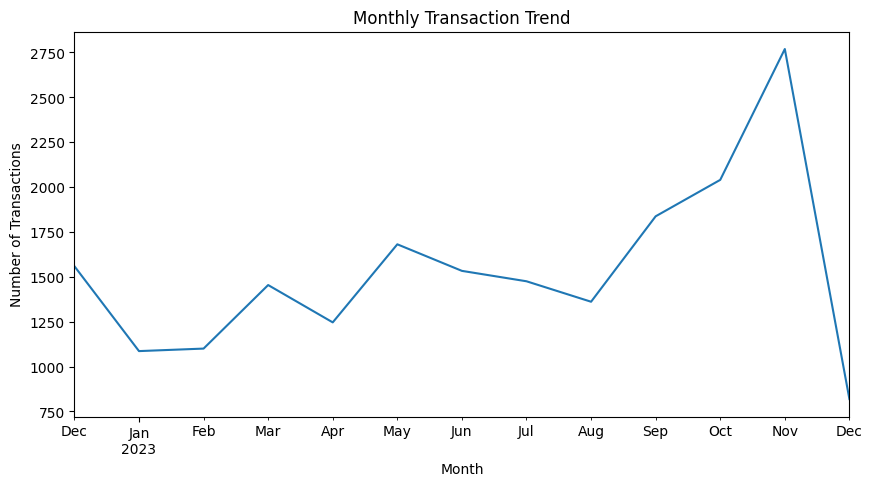

In [11]:
# Extract year-month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['InvoiceNo'].nunique()

plt.figure(figsize=(10, 5))
monthly_sales.plot()
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

# **Observation**

We can see that transactions increase during certain months and drop in others, showing seasonal buying behavior.
This helps understand when customers are more active and when sales are lower.

# **4. Distribution of Monetary Values**

# **A) Transaction Monetary Value**
Transaction Monetary Value shows how much money is spent in a single purchase or invoice line. Each data point represents one transaction, helping us understand typical order sizes and whether most purchases are small or large.

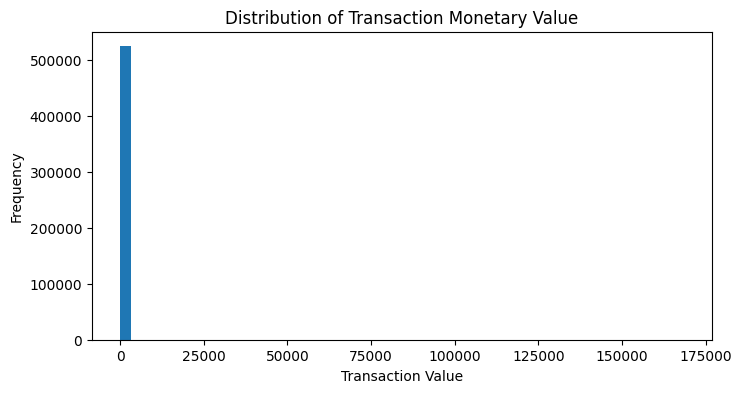

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df['TotalPrice'], bins=50)
plt.title("Distribution of Transaction Monetary Value")
plt.xlabel("Transaction Value")
plt.ylabel("Frequency")
plt.show()

Observation

Most transactions have a low value, while only a few transactions are very high in value.
This means sales are mostly made up of many small purchases rather than a few large ones.

# **B) Customer Spending Distribution**
Customer Spending Distribution, on the other hand, shows how much money a customer spends in total across all their purchases. Each data point represents one customer, helping us identify high-value customers who contribute significantly to overall revenue.

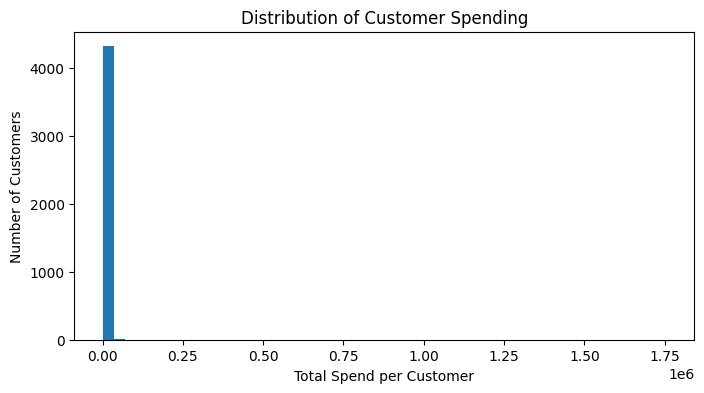

In [13]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()

plt.figure(figsize=(8, 4))
plt.hist(customer_spending, bins=50)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spend per Customer")
plt.ylabel("Number of Customers")
plt.show()

# **Observation**

Most customers spend a small amount, while only a few customers spend a lot.
This highlights the presence of high-value customers who contribute significantly to overall revenue.

# **STEP 3: CREATING RFM TABLE (Customer-Level Features)**

The original dataset is structured at the transaction level, where each row represents an individual purchase.
However, for customer segmentation, we need to analyze behavior at the customer level.

To achieve this, we create an RFM table, which summarizes each customer’s purchasing behavior using three key metrics:

# **RFM Metrics Explained**

Recency (R):
Number of days since the customer’s most recent purchase.
→ Indicates how recently a customer is engaged.

Frequency (F):
Total number of transactions made by the customer.
→ Measures how often a customer purchases.

Monetary (M):
Total amount spent by the customer.
→ Represents customer value to the business.

In [14]:
import pandas as pd

# This step is to get a Reference Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# df['InvoiceDate'].max() finds the most recent purchase date in the dataset.

# pd.Timedelta(days=1) adds one extra day to that date.




# Create RFM table
rfm = df.groupby('CustomerID').agg({ # this means all transactions of one customer are collected together.
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency Calculation = x represents all invoice dates of a single customer.

        # x.max() gets the latest purchase date of that customer.
        # snapshot_date - x.max() calculates how many days have passed since the last purchase.
        #.days converts the result into number of days.
    
    'InvoiceNo': 'nunique', # Frequency Calculation = Counts the number of unique invoices per customer.
    'TotalPrice': 'sum'     # Monetary Calculation = Adds up all the TotalPrice values for each customer.
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Converts CustomerID from an index back into a normal column.
rfm = rfm.reset_index()

# Display RFM table
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,-1,1,1428,1754901.91
1,12346,326,1,77183.60
2,12347,2,7,4310.00
3,12348,75,4,1797.24
4,12349,19,1,1757.55


# **RFM Distribution Plot**

This plot is used to visualize the distribution of Recency, Frequency, and Monetary values across all customers.

**Purpose of the RFM Plot**

To understand how customers are spread across recent activity, purchase frequency, and spending behavior

To identify skewness, outliers, and data imbalance in each RFM metric

To validate whether scaling or normalization is required before clustering

# **Key Observations Typically Seen**

Recency often shows a right-skewed distribution, indicating many inactive customers

Frequency is usually low for most customers, with a few highly frequent buyers

Monetary values are highly skewed, where a small percentage of customers contribute to a large portion of revenue

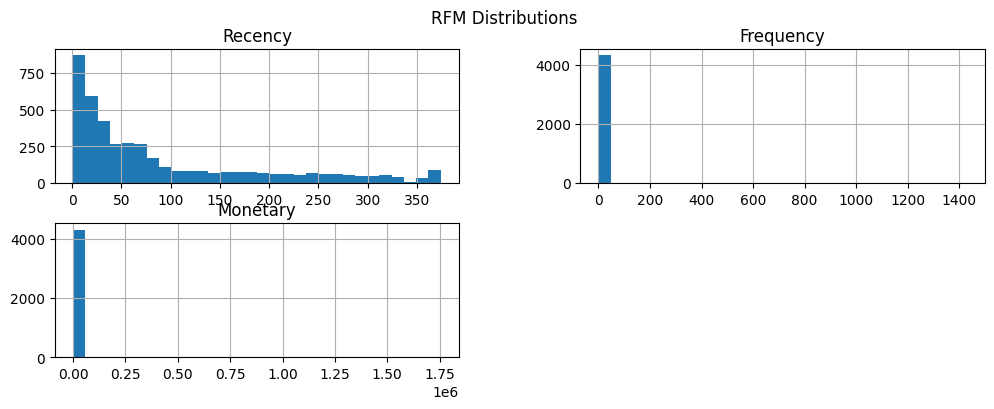

In [15]:
# RFM histograms
rfm[['Recency', 'Frequency', 'Monetary']].hist(figsize=(12, 4), bins=30)
plt.suptitle("RFM Distributions")
plt.show()

# **STEP 4: RFM SCALING** 

Recency, Frequency, and Monetary (RFM) values are measured on different scales:

- **Recency**: Number of days since the customer's last purchase (typically ranges from a few days to several hundred days).  
- **Frequency**: Total number of transactions per customer (usually a small integer).  
- **Monetary**: Total amount spent by the customer (can be very large, depending on the dataset).

If we directly apply clustering algorithms such as **K-Means** without scaling, the algorithm will be biased toward features with larger numeric ranges (e.g., Monetary), and the resulting clusters may not represent meaningful customer segments.

**Why Scaling is Important:**

- Ensures that each RFM feature contributes **equally** to the clustering process.  
- Prevents dominance of high-magnitude features like Monetary over smaller-scale features like Frequency.  
- Improves the performance and interpretability of clustering metrics such as inertia and silhouette score.

In this project, we will apply **StandardScaler** from `scikit-learn` to the RFM table to prepare it for clustering, ensuring unbiased and meaningful customer segmentation.

In [16]:
# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled array back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)


# Verify the Scaled Dataset
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.339000e+03,4.339000e+03,4.339000e+03
mean,5.240232e-17,1.146301e-17,-2.128844e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.151462e-01,-1.569313e-01,-8.720327e-02
25%,-7.451475e-01,-1.569313e-01,-7.642249e-02
50%,-4.151501e-01,-1.133409e-01,-6.352937e-02
75%,4.948429e-01,1.743011e-02,-2.819426e-02
max,2.814825e+00,6.204650e+01,6.240288e+01


# **Observation**
All RFM features are now on the same scale, so no single feature (like Monetary) will dominate the clustering algorithm. This makes the dataset ready and reliable for K-Means clustering.

# **STEP 5: Saving Processed Data and Models** 

After cleaning, transforming, and scaling the data, it is important to **save the datasets and models** for future use. This ensures that we do not need to repeat the preprocessing steps every time we want to use the data for clustering, customer segmentation, or building the Streamlit app.  

**What this code does:**

1. **Cleaned Transactional Data (`cleaned_online_retail.csv`)**  
   - Contains the raw transactional data after removing missing values, cancelled invoices, and invalid quantities/prices.  

2. **RFM Table (`rfm_table.csv`)**  
   - Contains customer-level features: Recency, Frequency, and Monetary values, ready for analysis.  

3. **Scaled RFM Data (`rfm_scaled.csv`)**  
   - Standardized version of the RFM table to ensure equal contribution of all features for clustering algorithms like K-Means.  

4. **Scaler Object (`rfm_scaler.pkl`)**  
   - Saves the StandardScaler used for RFM scaling.  
   - Useful for **real-time predictions** in the Streamlit app so that new customer data can be scaled consistently.  

**Benefits of Saving:**  
- Avoids repeated computation and preprocessing.  
- Ensures reproducibility of results.  
- Makes the datasets and models easily accessible for downstream tasks like clustering, segmentation, and product recommendation.

In [17]:
import joblib
import os


# Ensure directories exist
os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)


# Save the cleaned transactional data in the data folder
df.to_csv("../data/cleaned_online_retail.csv", index=False)

# Save the RFM table in the data folder
rfm.to_csv("../data/rfm_table.csv", index=False)

# Save the scaled RFM data in the data folder
rfm_scaled.to_csv("../data/rfm_scaled.csv", index=False)

# Save the scaler pickle file in the models folder
joblib.dump(scaler, "../models/rfm_scaler.pkl")  

print("Sucessfully Saved the Datasets")

Sucessfully Saved the Datasets
